# Part A — Movie / Social Network Analysis

This notebook implements Part A tasks A1-A7. I use the manual selections from `docs/part_a_instructions.md`:

- Selected movie/show for A1-A5: `2013_The_Wolf_of_Wall_Street`
- Graph embedding method for A1.2: basic graph-level feature vectors plus PCA
- Centrality method for A2 top-12: PageRank
- Ego-network vertex for A5: Jordan Belfort
- Chess strategy for A6: stream/chunk the compressed FICS edge list and analyze a sampled subgraph
- LOTR attributes for A7: `gender` for color and `race` for shape

The notebook keeps the important assignment code in cells so it is possible to inspect exactly how each result was produced.


## Setup and shared helpers

Before the tasks, I import the libraries, define paths, and create a few small helper functions that are reused in multiple cells. The Movie Dynamics files are NetworkX node-link JSON graphs inside a ZIP archive, so the loader reads a single JSON member from the archive without extracting the raw dataset.


In [1]:
from pathlib import Path
import csv
import io
import json
import math
import tarfile
import zipfile
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from networkx.readwrite import json_graph
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "exports" / "figures"
GEPHI_DIR = PROJECT_ROOT / "exports" / "gephi"
CYTOSCAPE_DIR = PROJECT_ROOT / "exports" / "cytoscape"

for path in [DATA_PROCESSED, FIGURES_DIR, GEPHI_DIR, CYTOSCAPE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MOVIE_ZIP = DATA_RAW / "movie_dynamics" / "movie-dynamics.zip"
SELECTED_MOVIE_ID = "2013_The_Wolf_of_Wall_Street"
SELECTED_MOVIE_MEMBER = f"moviedynamics/{SELECTED_MOVIE_ID}.json"
CHESS_ARCHIVE = DATA_RAW / "chess" / "fics.tar.gz"
LOTR_CSV = DATA_RAW / "lotr_couples" / "lotr_characters.csv"

required_files = {
    "Movie Dynamics ZIP": MOVIE_ZIP,
    "FICS chess archive": CHESS_ARCHIVE,
    "LOTR couples CSV": LOTR_CSV,
}
missing = [f"{name}: {path}" for name, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required Part A dataset files:\n" + "\n".join(missing))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)


def load_movie_graph(member_name: str) -> nx.Graph:
    """Load one Movie Dynamics graph from the ZIP archive as a NetworkX graph."""
    with zipfile.ZipFile(MOVIE_ZIP) as zf:
        data = json.loads(zf.read(member_name))
    graph = json_graph.node_link_graph(data, edges="links")
    graph.remove_edges_from(nx.selfloop_edges(graph))
    return graph


def safe_filename(text: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in text).strip("_")


def save_current_figure(filename: str) -> Path:
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path


def weighted_degree_dict(graph: nx.Graph) -> dict:
    return dict(graph.degree(weight="weight"))


def add_export_attributes(graph: nx.Graph) -> nx.Graph:
    """Return a copy with common node attributes useful in Cytoscape and Gephi."""
    exported = graph.copy()
    degrees = dict(exported.degree())
    weighted_degrees = weighted_degree_dict(exported)
    pagerank = nx.pagerank(exported, weight="weight") if exported.number_of_nodes() else {}
    triangles = nx.triangles(exported.to_undirected()) if exported.number_of_nodes() else {}
    for node in exported.nodes:
        exported.nodes[node]["label"] = str(node)
        exported.nodes[node]["degree"] = int(degrees.get(node, 0))
        exported.nodes[node]["weighted_degree"] = float(weighted_degrees.get(node, 0.0))
        exported.nodes[node]["pagerank"] = float(pagerank.get(node, 0.0))
        exported.nodes[node]["triangles"] = int(triangles.get(node, 0))
        exported.nodes[node]["viz_size"] = 10 + 3 * math.sqrt(max(degrees.get(node, 0), 0))
    for u, v, data in exported.edges(data=True):
        data["weight"] = float(data.get("weight", 1.0))
    return exported

print(f"Project root: {PROJECT_ROOT}")
print(f"Movie ZIP exists: {MOVIE_ZIP.exists()} ({MOVIE_ZIP.stat().st_size / 1024**2:.1f} MB)")
print(f"Chess archive exists: {CHESS_ARCHIVE.exists()} ({CHESS_ARCHIVE.stat().st_size / 1024**3:.1f} GB)")
print(f"LOTR CSV exists: {LOTR_CSV.exists()} ({LOTR_CSV.stat().st_size / 1024:.1f} KB)")


Project root: /home/roee/Desktop/network-analysis-assignment
Movie ZIP exists: True (29.5 MB)
Chess archive exists: True (6.4 GB)
LOTR CSV exists: True (50.6 KB)


## Dataset description

The Part A work uses three local datasets:

- **Movie Dynamics — Over 15,000 Movie Social Networks** from Kaggle. Local file: `data/raw/movie_dynamics/movie-dynamics.zip`. I use character-level JSON graphs, especially `moviedynamics/2013_The_Wolf_of_Wall_Street.json`.
- **Free Internet Chess Server network** from the University of Washington Network Dynamics site. Local file: `data/raw/chess/fics.tar.gz`. I stream a sample from `./FCIS/fcis_chess.interactions.csv` inside the archive and never load the full graph into NetworkX.
- **Lord of the Rings character couples CSV** from the local course/student file. Local file: `data/raw/lotr_couples/lotr_characters.csv`. I use `name`, `spouse`, `gender`, and `race`.

The next cell detects schemas and confirms the selected Movie Dynamics graph.


In [2]:
with zipfile.ZipFile(MOVIE_ZIP) as zf:
    movie_members = sorted(n for n in zf.namelist() if n.endswith(".json") and not n.endswith(".actors.json"))
    selected_info = zf.getinfo(SELECTED_MOVIE_MEMBER)
    selected_raw = json.loads(zf.read(SELECTED_MOVIE_MEMBER))

selected_graph = load_movie_graph(SELECTED_MOVIE_MEMBER)
lotr_preview = pd.read_csv(LOTR_CSV, nrows=5)

schema_summary = pd.DataFrame([
    {
        "dataset": "Movie Dynamics selected graph",
        "local_path": str(MOVIE_ZIP.relative_to(PROJECT_ROOT)),
        "file_used": SELECTED_MOVIE_MEMBER,
        "nodes": selected_graph.number_of_nodes(),
        "edges": selected_graph.number_of_edges(),
        "detected_columns_or_keys": ", ".join(selected_raw.keys()),
    },
    {
        "dataset": "LOTR couples",
        "local_path": str(LOTR_CSV.relative_to(PROJECT_ROOT)),
        "file_used": LOTR_CSV.name,
        "nodes": np.nan,
        "edges": np.nan,
        "detected_columns_or_keys": ", ".join(lotr_preview.columns),
    },
    {
        "dataset": "FICS chess interactions",
        "local_path": str(CHESS_ARCHIVE.relative_to(PROJECT_ROOT)),
        "file_used": "./FCIS/fcis_chess.interactions.csv inside tar.gz",
        "nodes": np.nan,
        "edges": np.nan,
        "detected_columns_or_keys": "datetime, src_id, dst_id",
    },
])

display(schema_summary)
print(f"Movie Dynamics graph members available: {len(movie_members):,}")
print(f"Selected graph metadata: {selected_graph.graph}")
print("First five selected graph nodes:", list(selected_graph.nodes(data=True))[:5])
print("First five selected graph edges:", list(selected_graph.edges(data=True))[:5])


,dataset,local_path,file_used,nodes,edges,detected_columns_or_keys
0,Movie Dynamics selected graph,data/raw/movie_dynamics/movie-dynamics.zip,moviedynamics/2013_The_Wolf_of_Wall_Street.json,49.0,297.0,"directed, multigraph, graph, nodes, links"
1,LOTR couples,data/raw/lotr_couples/lotr_characters.csv,lotr_characters.csv,NaN,NaN,"birth, death, gender, hair, height, name, race..."
2,FICS chess interactions,data/raw/chess/fics.tar.gz,./FCIS/fcis_chess.interactions.csv inside tar.gz,NaN,NaN,"datetime, src_id, dst_id"


Movie Dynamics graph members available: 15,538
Selected graph metadata: {'imdb_rating': 8.2, 'movie_name': 'The Wolf of Wall Street', 'movie_year': 2013}
First five selected graph nodes: [('Jordan Belfort', {'first': 27, 'last': 3571, 'role': 'Leonardo DiCaprio'}), ('Stratton Oakmont Commercial', {'first': 54, 'last': 2401, 'role': 'Edward Herrmann'}), ('Hostess on The Naomi', {'first': 113, 'last': 3582, 'role': 'Zineb Oukach'}), ('Donnie Azoff', {'first': 143, 'last': 3502, 'role': 'Jonah Hill'}), ('Skylar Belfort', {'first': 185, 'last': 3048, 'role': 'Shea Coleman'})]
First five selected graph edges: [('Jordan Belfort', 'Stratton Oakmont Commercial', {'first': 54, 'last': 2454, 'weight': 63}), ('Jordan Belfort', 'Hostess on The Naomi', {'first': 113, 'last': 3582, 'weight': 318}), ('Jordan Belfort', 'Donnie Azoff', {'first': 143, 'last': 3554, 'weight': 370}), ('Jordan Belfort', 'Skylar Belfort', {'first': 185, 'last': 3094, 'weight': 58}), ('Jordan Belfort', 'Brad Bodnick', {'firs

## A1.1 Degree Distribution

**Requirement.** Load the selected movie/show network, calculate the degree of every vertex, plot the degree distribution, and explain whether the network is centralized around a few characters or more evenly distributed.

**Method.** I treat the selected Movie Dynamics file as an undirected character interaction graph because the JSON says `directed=False`. A node is a character and an edge means the two characters interacted in the film. I calculate both unweighted degree, which counts how many distinct neighbors a character has, and weighted degree, which also uses the interaction weight from the dataset.

**Why this method.** Degree distribution is the simplest way to see whether a story network has one or two highly connected characters or a broader ensemble structure. For this movie, the student selected Jordan Belfort because he is expected to be central, so degree is a direct first check of that expectation.


,character,degree,weighted_degree
0,Jordan Belfort,48,2261
1,Hostess on The Naomi,40,860
2,Donnie Azoff,39,987
3,Brad Bodnick,26,302
4,Nicky Koskoff,26,237
5,Agent Patrick Denham,20,175
6,Stratton Broker #2,19,225
7,Steve Madden,18,380
8,Max Belfort,18,219
9,SEC Attorney #1,18,182


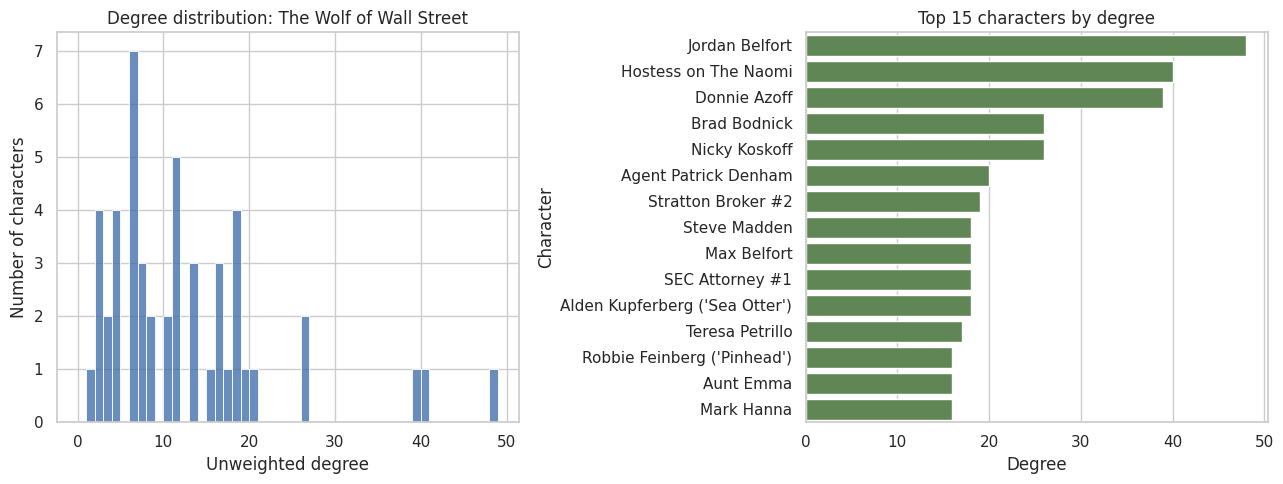

Saved figure: exports/figures/a1_1_degree_distribution.png
Highest-degree character: Jordan Belfort with degree 48.
Top character share of total degree: 8.08%


In [3]:
G = selected_graph
movie_title = G.graph.get("movie_name", SELECTED_MOVIE_ID).strip()

degree_df = pd.DataFrame({
    "character": list(G.nodes()),
    "degree": [G.degree(n) for n in G.nodes()],
    "weighted_degree": [G.degree(n, weight="weight") for n in G.nodes()],
}).sort_values(["degree", "weighted_degree"], ascending=False).reset_index(drop=True)

display(degree_df.head(15))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(degree_df["degree"], bins=range(0, int(degree_df["degree"].max()) + 2), ax=axes[0], color="#3769a8")
axes[0].set_title(f"Degree distribution: {movie_title}")
axes[0].set_xlabel("Unweighted degree")
axes[0].set_ylabel("Number of characters")

plot_df = degree_df.sort_values("degree", ascending=False).head(15)
sns.barplot(data=plot_df, y="character", x="degree", ax=axes[1], color="#5b8e4d")
axes[1].set_title("Top 15 characters by degree")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Character")
fig_path_a11 = save_current_figure("a1_1_degree_distribution.png")
plt.show()

centralization_ratio = degree_df.loc[0, "degree"] / degree_df["degree"].sum()
print(f"Saved figure: {fig_path_a11.relative_to(PROJECT_ROOT)}")
print(f"Highest-degree character: {degree_df.loc[0, 'character']} with degree {degree_df.loc[0, 'degree']}.")
print(f"Top character share of total degree: {centralization_ratio:.2%}")


**Interpretation.** The degree table and plot show how concentrated the selected movie network is. A long right tail means a few characters have many more distinct interactions than most others. In this graph, the top-ranked character has a much higher degree than ordinary minor characters, which fits a movie centered around Jordan Belfort and his close business/social circle.

### How I solved this task

I loaded `moviedynamics/2013_The_Wolf_of_Wall_Street.json` from the Movie Dynamics ZIP, converted it with NetworkX's node-link reader, calculated each character's degree and weighted degree, and plotted both the overall distribution and the top characters. I used ordinary degree for the distribution because the requirement asks for vertex degree and because it is easy to interpret as the number of distinct character contacts.

**Limitations.** Degree does not know when interactions happen in the film and does not distinguish short scenes from long scenes unless the weighted degree is also inspected. It also does not show whether a character connects otherwise separate groups.


## A1.2 Graph Embeddings of Movie Networks

**Requirement.** Load multiple movie/show networks, create one vector per graph, reduce those vectors to 2D, visualize them as points, and identify interesting clusters or pairs.

**Method.** The selected manual method is **basic graph-level feature vectors + PCA**. For each movie graph I calculate interpretable structural features: node count, edge count, density, average clustering, degree mean/std/max, weighted degree mean/max, component count, largest component share, and average shortest path on the largest component when feasible. Then I standardize the feature table and use PCA to project it into two dimensions.

**Why this method.** This method is transparent. Each coordinate is produced from structural summaries that can be explained, unlike a more complex embedding model where the dimensions are harder to interpret. PCA is useful here because it shows which movies have similar graph shapes without requiring a supervised label.


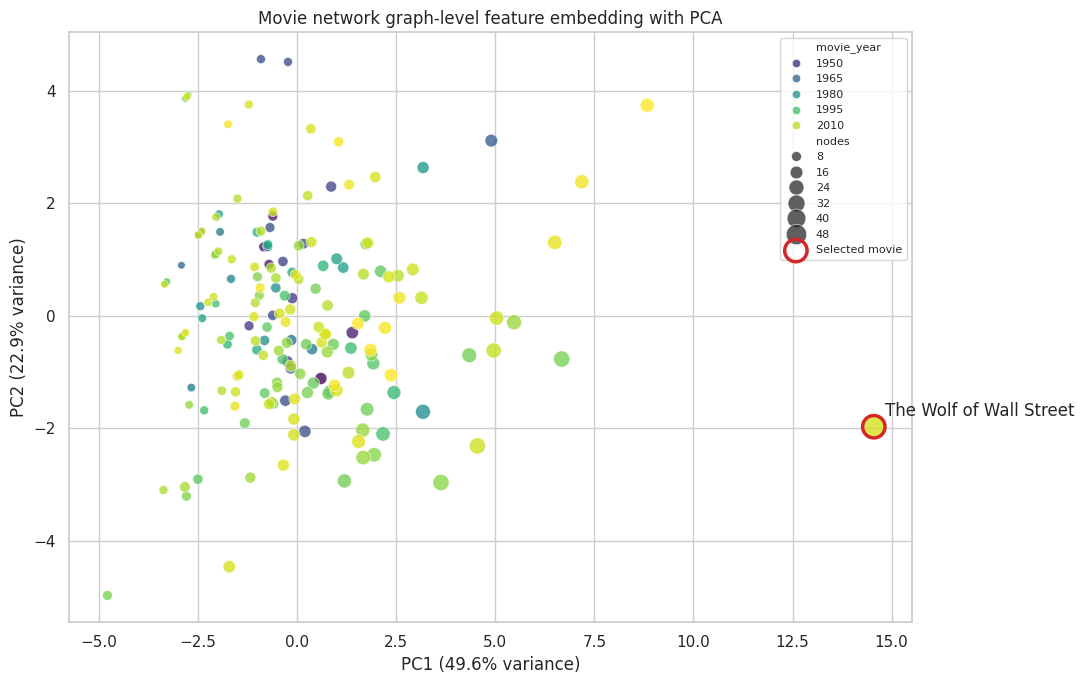

,movie_name,nodes,edges,density,average_clustering,degree_max,largest_component_share
0,The Wolf of Wall Street,49,297,0.252551,0.775281,48.0,1.0


,movie_name,movie_year,nodes,edges,density,average_clustering,distance_to_selected
0,The Wolf of Wall Street,2013,49,297,0.252551,0.775281,0.000000
77,Red Dragon,2002,29,140,0.344828,0.750904,7.967172
178,The Guernsey Literary and Potato Peel Pie Society,2018,21,125,0.595238,0.831259,8.086636
171,Miracles from Heaven,2016,21,122,0.580952,0.792715,8.559741
166,Our Brand Is Crisis,2015,22,107,0.463203,0.762408,8.694492
97,The Wind that Shakes the Barley,2006,24,113,0.409420,0.770553,9.267353
129,Tinker Tailor Soldier Spy,2011,25,116,0.386667,0.714271,9.689431
131,End of Watch,2012,22,84,0.363636,0.673157,9.712978
134,Mea Maxima Culpa: Silence in the House of God,2012,29,87,0.214286,0.579111,10.010682
68,I Am Sam,2001,23,79,0.312253,0.772866,10.288578


,PC1_loading,PC2_loading
degree_max,0.388879,-0.117547
edges,0.386966,-0.031852
degree_std,0.385652,-0.150633
degree_mean,0.373742,0.157113
nodes,0.371323,-0.219495
weighted_degree_max,0.348038,0.131255
weighted_degree_mean,0.283328,0.272935
average_clustering,0.189614,0.355451


Saved figure: exports/figures/a1_2_movie_graph_embedding.png
Feature cache: data/processed/part_a_movie_graph_features.parquet


In [4]:
def graph_feature_row(member_name: str) -> dict:
    graph = load_movie_graph(member_name)
    undirected = graph.to_undirected()
    n = graph.number_of_nodes()
    m = graph.number_of_edges()
    degrees = np.array([d for _, d in graph.degree()], dtype=float)
    weighted_degrees = np.array([d for _, d in graph.degree(weight="weight")], dtype=float)
    components = list(nx.connected_components(undirected)) if n else []
    largest_component_size = max((len(c) for c in components), default=0)
    largest_share = largest_component_size / n if n else 0
    largest_avg_path = np.nan
    if 1 < largest_component_size <= 300:
        sub = undirected.subgraph(max(components, key=len)).copy()
        largest_avg_path = nx.average_shortest_path_length(sub)
    return {
        "member": member_name,
        "movie_id": Path(member_name).stem,
        "movie_name": graph.graph.get("movie_name", Path(member_name).stem).strip(),
        "movie_year": graph.graph.get("movie_year"),
        "nodes": n,
        "edges": m,
        "density": nx.density(graph) if n > 1 else 0,
        "average_clustering": nx.average_clustering(undirected, weight=None) if n > 1 else 0,
        "degree_mean": float(degrees.mean()) if len(degrees) else 0,
        "degree_std": float(degrees.std()) if len(degrees) else 0,
        "degree_max": float(degrees.max()) if len(degrees) else 0,
        "weighted_degree_mean": float(weighted_degrees.mean()) if len(weighted_degrees) else 0,
        "weighted_degree_max": float(weighted_degrees.max()) if len(weighted_degrees) else 0,
        "component_count": len(components),
        "largest_component_share": largest_share,
        "largest_component_avg_path": largest_avg_path,
    }

# Use a deterministic sample across the archive so the embedding is broad but quick to rerun.
embedding_cache = DATA_PROCESSED / "part_a_movie_graph_features.parquet"
if embedding_cache.exists():
    feature_df = pd.read_parquet(embedding_cache)
else:
    with zipfile.ZipFile(MOVIE_ZIP) as zf:
        all_members = sorted(n for n in zf.namelist() if n.endswith(".json") and not n.endswith(".actors.json"))
    rng = np.random.default_rng(RANDOM_SEED)
    sample_size = min(180, len(all_members))
    sampled_members = sorted(rng.choice(all_members, size=sample_size, replace=False).tolist())
    if SELECTED_MOVIE_MEMBER not in sampled_members:
        sampled_members[0] = SELECTED_MOVIE_MEMBER
    rows = [graph_feature_row(member) for member in sampled_members]
    feature_df = pd.DataFrame(rows)
    feature_df.to_parquet(embedding_cache, index=False)

feature_columns = [
    "nodes", "edges", "density", "average_clustering", "degree_mean", "degree_std", "degree_max",
    "weighted_degree_mean", "weighted_degree_max", "component_count", "largest_component_share", "largest_component_avg_path",
]
features_for_pca = feature_df[feature_columns].copy()
features_for_pca = features_for_pca.fillna(features_for_pca.median(numeric_only=True))
scaled_features = StandardScaler().fit_transform(features_for_pca)
pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(scaled_features)
embedding_df = feature_df.copy()
embedding_df["PC1"] = coords[:, 0]
embedding_df["PC2"] = coords[:, 1]
embedding_df["is_selected_movie"] = embedding_df["member"].eq(SELECTED_MOVIE_MEMBER)

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=embedding_df, x="PC1", y="PC2", size="nodes", hue="movie_year", palette="viridis", sizes=(30, 220), alpha=0.78, ax=ax)
selected_row = embedding_df[embedding_df["is_selected_movie"]].iloc[0]
ax.scatter([selected_row["PC1"]], [selected_row["PC2"]], s=260, facecolors="none", edgecolors="#d62728", linewidths=2.5, label="Selected movie")
ax.annotate("The Wolf of Wall Street", (selected_row["PC1"], selected_row["PC2"]), xytext=(8, 8), textcoords="offset points")
ax.set_title("Movie network graph-level feature embedding with PCA")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(loc="best", fontsize=8)
fig_path_a12 = save_current_figure("a1_2_movie_graph_embedding.png")
plt.show()

display(feature_df.loc[feature_df["member"].eq(SELECTED_MOVIE_MEMBER), ["movie_name", "nodes", "edges", "density", "average_clustering", "degree_max", "largest_component_share"]])
nearest = embedding_df.assign(
    distance_to_selected=np.sqrt((embedding_df["PC1"] - selected_row["PC1"])**2 + (embedding_df["PC2"] - selected_row["PC2"])**2)
).sort_values("distance_to_selected").head(10)
display(nearest[["movie_name", "movie_year", "nodes", "edges", "density", "average_clustering", "distance_to_selected"]])

loadings = pd.DataFrame(pca.components_.T, index=feature_columns, columns=["PC1_loading", "PC2_loading"])
display(loadings.sort_values("PC1_loading", key=abs, ascending=False).head(8))
print(f"Saved figure: {fig_path_a12.relative_to(PROJECT_ROOT)}")
print(f"Feature cache: {embedding_cache.relative_to(PROJECT_ROOT)}")


**Interpretation.** Points close together have similar graph summaries, not necessarily similar genres or plots. The nearest-neighbor table lists movie networks that are structurally close to the selected movie under these features. The PCA loading table shows which features most influenced the first two axes, so I can tell whether the visualization is mainly separating large dense graphs, sparse graphs, fragmented graphs, or graphs with strong clustering.

### How I solved this task

I sampled 180 movie networks deterministically from the Movie Dynamics archive, made one row of structural features per graph, standardized the columns, and used PCA to reduce the feature vectors to two dimensions. I highlighted `The Wolf of Wall Street` and printed the closest graph points in the PCA space.

**Limitations.** This embedding captures graph shape only. It ignores character names, plot content, genre, scene order, and dialogue. PCA is also linear, so curved or more complex similarities may not appear cleanly in two dimensions.


## A2 Top-12 Character Subgraph with PageRank

**Requirement.** Use the selected centrality algorithm to rank characters, select the top 12, create the induced subgraph, draw it in a circular layout, and explain why that centrality method was selected.

**Method.** The selected method is **PageRank**. I compute weighted PageRank on the selected undirected graph. In an undirected graph, PageRank behaves like a prestige score where a character receives more importance from being connected to other important characters, and edge weights allow stronger interactions to contribute more.

**Why this method.** PageRank is appropriate because a movie character can matter through direct interactions and through ties to already important characters. It is more informative than degree alone when a character is connected to a central part of the story network.


,character,pagerank,degree,weighted_degree
0,Jordan Belfort,0.239908,48,2261
1,Donnie Azoff,0.100026,39,987
2,Hostess on The Naomi,0.088716,40,860
3,Steve Madden,0.038356,18,380
4,Brad Bodnick,0.032348,26,302
5,Nicky Koskoff,0.027349,26,237
6,Max Belfort,0.025248,18,219
7,Stratton Broker #2,0.024350,19,225
8,SEC Attorney #1,0.020379,18,182
9,Agent Patrick Denham,0.020208,20,175


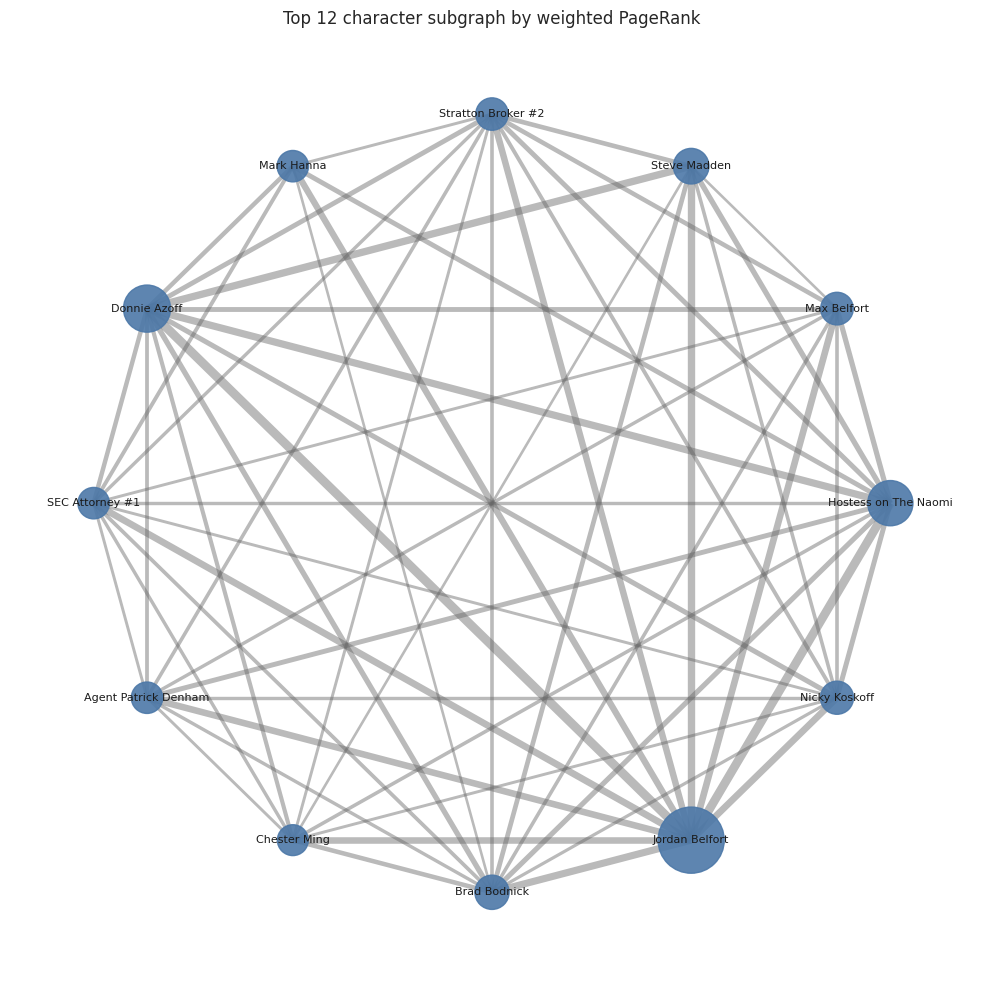

Top-12 subgraph nodes: 12, edges: 58
Saved figure: exports/figures/a2_top12_pagerank_subgraph.png


In [5]:
pagerank = nx.pagerank(G, weight="weight")
centrality_df = pd.DataFrame({
    "character": list(pagerank.keys()),
    "pagerank": list(pagerank.values()),
    "degree": [G.degree(n) for n in pagerank.keys()],
    "weighted_degree": [G.degree(n, weight="weight") for n in pagerank.keys()],
}).sort_values("pagerank", ascending=False).reset_index(drop=True)

top12_characters = centrality_df.head(12)["character"].tolist()
top12_subgraph = G.subgraph(top12_characters).copy()

display(centrality_df.head(12))

pos = nx.circular_layout(top12_subgraph)
node_sizes = [8000 * pagerank[node] + 350 for node in top12_subgraph.nodes()]
edge_widths = [0.5 + math.log1p(top12_subgraph[u][v].get("weight", 1)) for u, v in top12_subgraph.edges()]
plt.figure(figsize=(10, 10))
nx.draw_networkx_edges(top12_subgraph, pos, width=edge_widths, alpha=0.45, edge_color="#666666")
nx.draw_networkx_nodes(top12_subgraph, pos, node_size=node_sizes, node_color="#4c78a8", alpha=0.9)
nx.draw_networkx_labels(top12_subgraph, pos, font_size=8)
plt.title("Top 12 character subgraph by weighted PageRank")
plt.axis("off")
fig_path_a2 = save_current_figure("a2_top12_pagerank_subgraph.png")
plt.show()
print(f"Top-12 subgraph nodes: {top12_subgraph.number_of_nodes()}, edges: {top12_subgraph.number_of_edges()}")
print(f"Saved figure: {fig_path_a2.relative_to(PROJECT_ROOT)}")


**Interpretation.** The top-12 subgraph keeps only the most PageRank-central characters and the interactions among them. If many edges remain inside the induced subgraph, the main characters form a closely connected story core. If some top characters have fewer ties inside this view, their PageRank may be coming from strong weighted interactions or from bridging to important characters outside the top 12.

### How I solved this task

I ran NetworkX weighted PageRank on the selected movie graph, sorted the characters, selected the first 12, and drew the induced subgraph using a circular layout. I scaled node sizes by PageRank and edge widths by the log of interaction weight so that strong ties remain visible without making the drawing unreadable.

**Limitations.** PageRank depends on the interaction weights from the dataset. If the weight does not perfectly represent narrative importance, the ranking can overvalue long or repeated interactions that are not central to the plot.


## A3 PageRank, Triangles, and Average Shortest Paths

**Requirement.** For every vertex in the selected graph, compute PageRank, the number of triangles, and average shortest path length. If the graph is directed, explain the conversion decision.

**Method.** The selected Movie Dynamics graph is undirected, so no directed conversion is needed. PageRank uses edge weights. Triangle counts use the undirected graph and count how many closed three-character interaction patterns include each character. Average shortest path length is calculated from each character to all reachable characters in its connected component.

**Why this method.** These three measures describe different roles: PageRank captures global importance, triangles capture local clustering, and average shortest path length captures how close a character is to the rest of the reachable graph.


,character,pagerank,triangles,avg_shortest_path_to_reachable,degree,weighted_degree,component_id
0,Jordan Belfort,0.239908,249,1.000000,48,2261,0
1,Donnie Azoff,0.100026,226,1.187500,39,987,0
2,Hostess on The Naomi,0.088716,236,1.166667,40,860,0
3,Steve Madden,0.038356,94,1.625000,18,380,0
4,Brad Bodnick,0.032348,157,1.458333,26,302,0
5,Nicky Koskoff,0.027349,143,1.458333,26,237,0
6,Max Belfort,0.025248,87,1.625000,18,219,0
7,Stratton Broker #2,0.024350,118,1.604167,19,225,0
8,SEC Attorney #1,0.020379,103,1.625000,18,182,0
9,Agent Patrick Denham,0.020208,111,1.583333,20,175,0


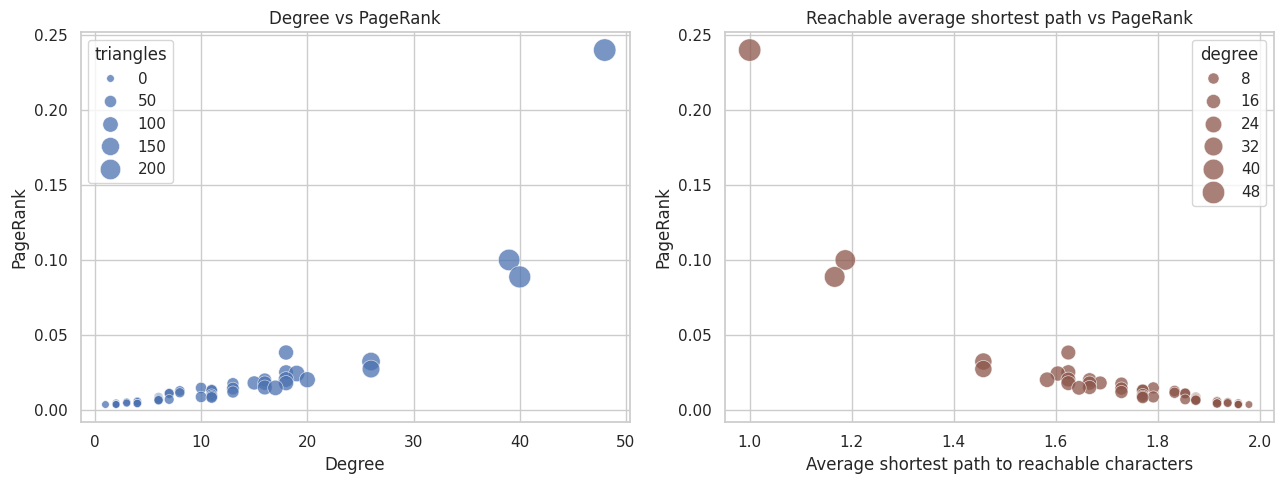

Graph directed? False
Connected components: 1
Saved figure: exports/figures/a3_pagerank_triangles_shortest_paths.png


In [6]:
triangles = nx.triangles(G)
component_lookup = {}
for component_id, component_nodes in enumerate(nx.connected_components(G)):
    for node in component_nodes:
        component_lookup[node] = component_id

avg_shortest_paths = {}
for component_nodes in nx.connected_components(G):
    sub = G.subgraph(component_nodes)
    if sub.number_of_nodes() == 1:
        only_node = next(iter(sub.nodes()))
        avg_shortest_paths[only_node] = 0.0
    else:
        lengths = dict(nx.all_pairs_shortest_path_length(sub))
        for node, node_lengths in lengths.items():
            avg_shortest_paths[node] = np.mean([dist for other, dist in node_lengths.items() if other != node])

a3_df = pd.DataFrame({
    "character": list(G.nodes()),
    "pagerank": [pagerank[n] for n in G.nodes()],
    "triangles": [triangles[n] for n in G.nodes()],
    "avg_shortest_path_to_reachable": [avg_shortest_paths[n] for n in G.nodes()],
    "degree": [G.degree(n) for n in G.nodes()],
    "weighted_degree": [G.degree(n, weight="weight") for n in G.nodes()],
    "component_id": [component_lookup[n] for n in G.nodes()],
}).sort_values(["pagerank", "triangles"], ascending=False).reset_index(drop=True)

display(a3_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=a3_df, x="degree", y="pagerank", size="triangles", sizes=(30, 260), alpha=0.75, ax=axes[0])
axes[0].set_title("Degree vs PageRank")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("PageRank")
sns.scatterplot(data=a3_df, x="avg_shortest_path_to_reachable", y="pagerank", size="degree", sizes=(30, 260), alpha=0.75, ax=axes[1], color="#8c564b")
axes[1].set_title("Reachable average shortest path vs PageRank")
axes[1].set_xlabel("Average shortest path to reachable characters")
axes[1].set_ylabel("PageRank")
fig_path_a3 = save_current_figure("a3_pagerank_triangles_shortest_paths.png")
plt.show()

print(f"Graph directed? {G.is_directed()}")
print(f"Connected components: {nx.number_connected_components(G)}")
print(f"Saved figure: {fig_path_a3.relative_to(PROJECT_ROOT)}")


**Interpretation.** High PageRank and short average paths usually indicate a character near the center of the interaction network. Triangle counts identify characters embedded in groups where their neighbors also interact with each other. The table sorted by PageRank makes it possible to compare global importance with local group structure.

### How I solved this task

I reused the weighted PageRank scores from A2, computed triangle counts with `nx.triangles`, and calculated average shortest path length within each connected component. For isolated vertices the value is `0.0`; for disconnected graphs I do not average over unreachable vertices because there is no finite path to them.

**Limitations.** Shortest paths are based on unweighted graph distance, not scene duration or interaction strength. This is acceptable for a medium movie graph, but it simplifies the meaning of social distance.


## A4 Cytoscape and Gephi Exports

**Requirement.** Export the selected network to Cytoscape-compatible and Gephi-compatible formats, make vertex size correlate with degree, and include screenshot placeholders and manual styling instructions.

**Method.** I export the selected movie graph with node attributes for label, degree, weighted degree, PageRank, triangles, and `viz_size`. Cytoscape can read GraphML and Gephi can read GEXF. The `viz_size` attribute is calculated from degree so both tools can map node size consistently.

**Why this method.** GraphML and GEXF preserve node and edge attributes better than a plain edge list. That makes manual GUI styling easier and avoids recalculating centrality inside the visualization tools.


In [7]:
export_graph = add_export_attributes(G)
cytoscape_movie_path = CYTOSCAPE_DIR / "wolf_of_wall_street_character_network.graphml"
gephi_movie_path = GEPHI_DIR / "wolf_of_wall_street_character_network.gexf"
nx.write_graphml(export_graph, cytoscape_movie_path)
nx.write_gexf(export_graph, gephi_movie_path)

export_summary = pd.DataFrame([
    {"tool": "Cytoscape", "file": str(cytoscape_movie_path.relative_to(PROJECT_ROOT)), "format": "GraphML", "nodes": export_graph.number_of_nodes(), "edges": export_graph.number_of_edges()},
    {"tool": "Gephi", "file": str(gephi_movie_path.relative_to(PROJECT_ROOT)), "format": "GEXF", "nodes": export_graph.number_of_nodes(), "edges": export_graph.number_of_edges()},
])
display(export_summary)
print("Node attributes exported:", sorted(next(iter(export_graph.nodes(data=True)))[1].keys()))


,tool,file,format,nodes,edges
0,Cytoscape,exports/cytoscape/wolf_of_wall_street_characte...,GraphML,49,297
1,Gephi,exports/gephi/wolf_of_wall_street_character_ne...,GEXF,49,297


Node attributes exported: ['degree', 'first', 'label', 'last', 'pagerank', 'role', 'triangles', 'viz_size', 'weighted_degree']


### Cytoscape screenshot: Wolf of Wall Street character network

![Cytoscape visualization of the Wolf of Wall Street character network](../exports/figures/cytoscape_wolf_of_wall_street_character_relations.png)

This Cytoscape view emphasizes the selected movie's character interaction structure. Larger nodes represent higher degree, so the most connected characters stand out visually, while the edge layout shows how the main story group is surrounded by smaller local interaction groups.

Suggested Cytoscape styling used for this screenshot:

1. Import the GraphML file as a network.
2. Set node label to `label`.
3. Map node size to `viz_size` or `degree`.
4. Map node color to `pagerank` using a sequential color scale.
5. Map edge width to `weight`.
6. Use a force-directed layout, then manually move labels if needed.

### Gephi screenshot: Wolf of Wall Street character network

![Gephi visualization of the Wolf of Wall Street character network](../exports/figures/gephi_wolf_of_wall_street_character_relations.png)

This Gephi view provides a second layout of the same exported graph. The visualization makes the dense central component visible and helps compare whether the same high-degree/PageRank characters remain prominent when a different graph layout tool is used.

Suggested Gephi styling used for this screenshot:

1. Open the GEXF file in Gephi.
2. Use ForceAtlas2 or Fruchterman-Reingold layout.
3. Rank node size by `degree` or `viz_size`.
4. Color nodes by `pagerank` or `triangles`.
5. Rank edge thickness by `weight`.
6. Enable labels and adjust label size so character names remain readable.

**Interpretation.** These exports contain the same selected graph used in A1-A3, but with extra attributes for GUI visualization. The screenshots show that the selected movie network has a visible central group, with the largest nodes acting as the main interaction anchors.

### How I solved this task

I copied the selected movie graph, added degree-based visualization attributes, PageRank, triangles, labels, and edge weights, then exported GraphML for Cytoscape and GEXF for Gephi. The size field is based on degree because the requirement asks for vertex size to correlate with degree. After creating the exports, I inserted the manually created Cytoscape and Gephi screenshots into this notebook.

**Limitations.** Cytoscape and Gephi layouts are partly manual and can change with styling choices. The screenshots document one readable layout rather than a unique mathematical result.


## A5 Ego Network Function

**Requirement.** Write a function that receives a selected vertex and creates a subgraph containing the selected vertex, all incoming neighbors, and all outgoing neighbors. Then draw it, calculate its number of vertices and edges, and explain what it reveals.

**Method.** The selected graph is undirected, so incoming and outgoing neighbors are the same set. I still write the function so it works for directed graphs: for directed graphs it combines predecessors and successors; for undirected graphs it uses ordinary neighbors.

**Why this method.** An ego network focuses on the local neighborhood of one character. The student selected Jordan Belfort because he is the main character, so this view shows the characters directly attached to him and the ties among those neighbors.


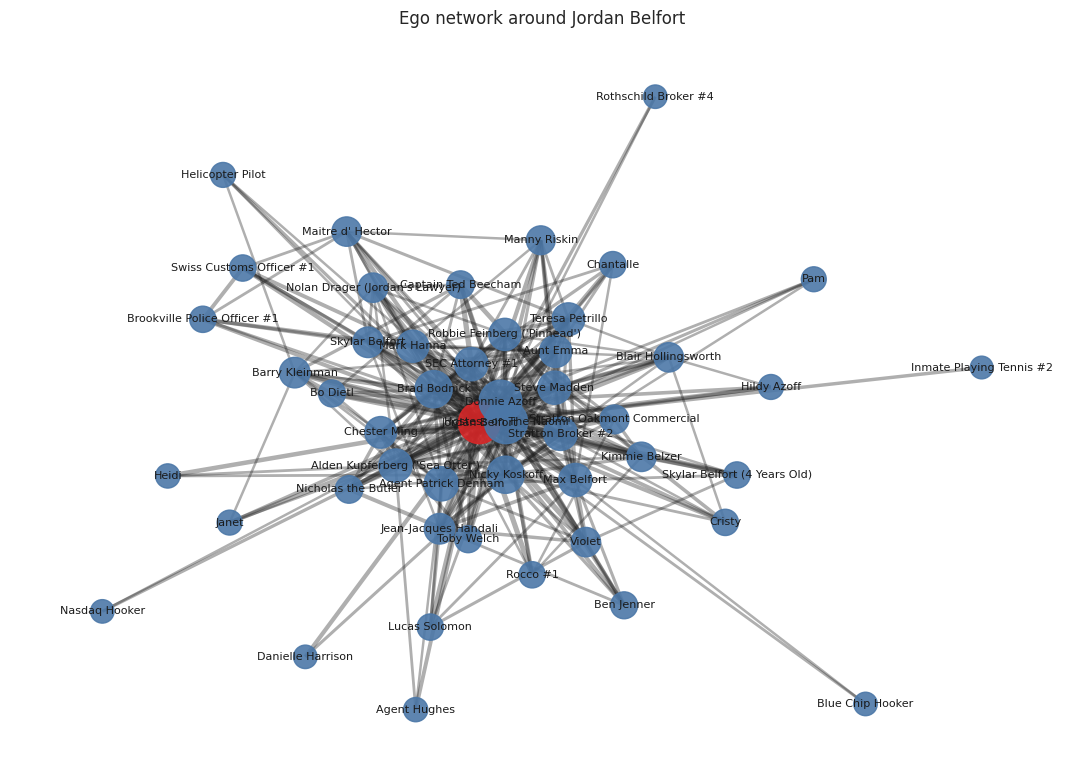

,selected_vertex,ego_nodes,ego_edges,selected_vertex_degree_in_full_graph,selected_vertex_weighted_degree
0,Jordan Belfort,49,297,48,2261


,neighbor,degree_inside_ego,weighted_degree_inside_ego
2,Donnie Azoff,39,987
1,Hostess on The Naomi,40,860
26,Steve Madden,18,380
4,Brad Bodnick,26,302
22,Nicky Koskoff,26,237
18,Stratton Broker #2,19,225
20,Max Belfort,18,219
8,SEC Attorney #1,18,182
19,Agent Patrick Denham,20,175
9,Mark Hanna,16,167


Saved figure: exports/figures/a5_jordan_belfort_ego_network.png


In [8]:
def ego_network_in_out(graph: nx.Graph, vertex: str) -> nx.Graph:
    if vertex not in graph:
        lowered = {str(node).lower(): node for node in graph.nodes()}
        matches = [node for node in graph.nodes() if str(vertex).lower() in str(node).lower() or str(node).lower() in str(vertex).lower()]
        if matches:
            vertex = matches[0]
        elif str(vertex).lower() in lowered:
            vertex = lowered[str(vertex).lower()]
        else:
            raise ValueError(f"Vertex {vertex!r} was not found. Example nodes: {list(graph.nodes())[:10]}")
    if graph.is_directed():
        neighbors = set(graph.predecessors(vertex)) | set(graph.successors(vertex))
    else:
        neighbors = set(graph.neighbors(vertex))
    return graph.subgraph({vertex, *neighbors}).copy()

selected_vertex = "Jordan Belfort"
ego = ego_network_in_out(G, selected_vertex)
weighted_ego_degree = dict(ego.degree(weight="weight"))

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(ego, seed=RANDOM_SEED, weight="weight", k=0.7)
node_colors = ["#d62728" if node == selected_vertex else "#4c78a8" for node in ego.nodes()]
node_sizes = [900 if node == selected_vertex else 250 + 18 * ego.degree(node) for node in ego.nodes()]
edge_widths = [0.4 + math.log1p(ego[u][v].get("weight", 1)) for u, v in ego.edges()]
nx.draw_networkx_edges(ego, pos, width=edge_widths, alpha=0.35)
nx.draw_networkx_nodes(ego, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(ego, pos, font_size=8)
plt.title(f"Ego network around {selected_vertex}")
plt.axis("off")
fig_path_a5 = save_current_figure("a5_jordan_belfort_ego_network.png")
plt.show()

ego_summary = pd.DataFrame([
    {"selected_vertex": selected_vertex, "ego_nodes": ego.number_of_nodes(), "ego_edges": ego.number_of_edges(), "selected_vertex_degree_in_full_graph": G.degree(selected_vertex), "selected_vertex_weighted_degree": G.degree(selected_vertex, weight="weight")}
])
display(ego_summary)

ego_neighbor_table = pd.DataFrame({
    "neighbor": [node for node in ego.nodes() if node != selected_vertex],
    "degree_inside_ego": [ego.degree(node) for node in ego.nodes() if node != selected_vertex],
    "weighted_degree_inside_ego": [weighted_ego_degree[node] for node in ego.nodes() if node != selected_vertex],
}).sort_values(["weighted_degree_inside_ego", "degree_inside_ego"], ascending=False)
display(ego_neighbor_table.head(20))
print(f"Saved figure: {fig_path_a5.relative_to(PROJECT_ROOT)}")


**Interpretation.** Jordan Belfort's ego network contains his direct interaction partners and the edges among those partners. A dense ego network would mean many of his contacts also interact with each other; a sparse ego network would mean he connects otherwise separate parts of the story. The neighbor table helps identify which direct contacts have the strongest presence inside this local neighborhood.

### How I solved this task

I wrote `ego_network_in_out`, which handles directed graphs by combining predecessors and successors and handles this undirected movie graph by using ordinary neighbors. Then I drew Jordan Belfort's ego graph, counted its nodes and edges, and ranked neighbors by weighted degree inside the ego network.

**Limitations.** Because this graph is undirected, incoming and outgoing neighbors cannot be distinguished. The ego network also only shows one-hop contacts, so it hides characters that are important through two-step paths.


## A6 Large Chess Network Analysis

**Requirement.** Use the Free Internet Chess Server network, find the top 10 most central players, visualize a meaningful part of the network, and explain how the large network size was handled.

**Method.** The chess archive contains a very large interactions CSV. I do **not** load the full graph into NetworkX. Instead, I stream a limited number of interaction rows from the compressed archive, count how often each player appears as a source or destination, and use that interaction count as a scalable degree-like centrality approximation. Then I build a small visualization subgraph using the top sampled players and a limited number of their sampled neighbors.

**Why this method.** The assignment explicitly warns that the FICS graph is too large for a full NetworkX load. Counting endpoints in streamed edges is memory-safe and gives a reasonable approximation of highly active or central players in the sampled interaction data.


,player,sampled_interaction_count
0,FriarTuck,6830
1,Wronskian,6032
2,mscp,4098
3,secone,2688
4,stupido,1566
5,Urania,1510
6,pkch,1370
7,blindfolded,1330
8,JagorCrafty,1296
9,hdyl,1178


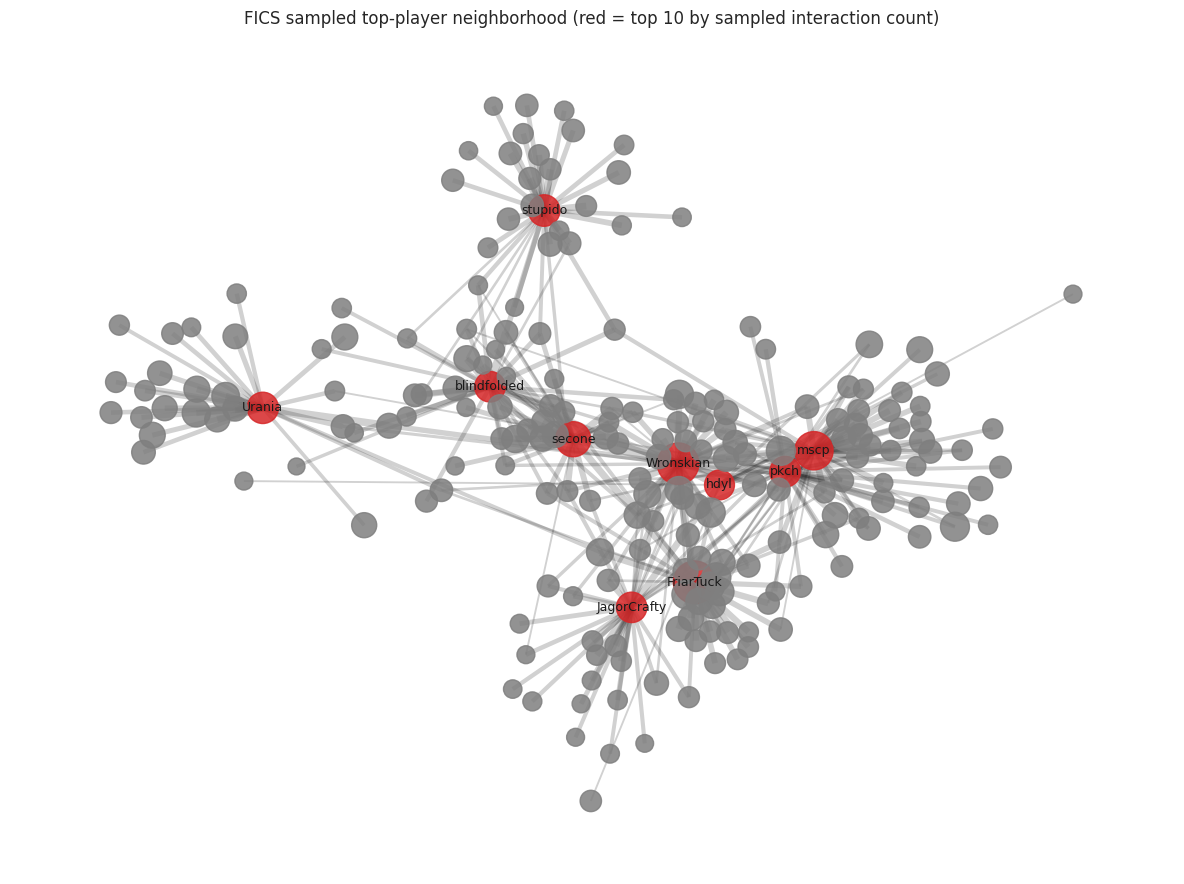

Chess cache status: created cache from streamed tar.gz sample
Rows analyzed: 200,000
Sample visualization graph: 214 nodes, 314 edges
Saved figure: exports/figures/a6_fics_sampled_top_players.png
Exported sampled chess GraphML: exports/cytoscape/fics_sampled_top_players.graphml
Exported sampled chess GEXF: exports/gephi/fics_sampled_top_players.gexf


In [9]:
CHESS_SAMPLE_ROWS = 200_000
CHESS_NEIGHBORS_PER_TOP_PLAYER = 25
chess_edges_cache = DATA_PROCESSED / f"fics_interactions_first_{CHESS_SAMPLE_ROWS}.parquet"


def stream_chess_interactions_sample(max_rows: int) -> pd.DataFrame:
    rows = []
    with tarfile.open(CHESS_ARCHIVE, "r:gz") as tar:
        member = tar.getmember("./FCIS/fcis_chess.interactions.csv")
        file_obj = tar.extractfile(member)
        text = io.TextIOWrapper(file_obj, encoding="utf-8", newline="")
        reader = csv.DictReader(text)
        for idx, row in enumerate(reader):
            if idx >= max_rows:
                break
            rows.append({"datetime": row["datetime"], "src_id": row["src_id"], "dst_id": row["dst_id"]})
    return pd.DataFrame(rows)

if chess_edges_cache.exists():
    chess_edges = pd.read_parquet(chess_edges_cache)
    cache_status = "loaded existing cache"
else:
    chess_edges = stream_chess_interactions_sample(CHESS_SAMPLE_ROWS)
    chess_edges.to_parquet(chess_edges_cache, index=False)
    cache_status = "created cache from streamed tar.gz sample"

endpoint_counts = pd.concat([chess_edges["src_id"], chess_edges["dst_id"]]).value_counts()
top_chess_players = endpoint_counts.head(10).rename_axis("player").reset_index(name="sampled_interaction_count")
display(top_chess_players)

selected_players = set(top_chess_players["player"])
subgraph_edges = []
neighbor_counts = defaultdict(Counter)
for row in chess_edges.itertuples(index=False):
    src = row.src_id
    dst = row.dst_id
    if src in selected_players:
        neighbor_counts[src][dst] += 1
    if dst in selected_players:
        neighbor_counts[dst][src] += 1

allowed_nodes = set(selected_players)
for player, counts in neighbor_counts.items():
    for neighbor, _ in counts.most_common(CHESS_NEIGHBORS_PER_TOP_PLAYER):
        allowed_nodes.add(neighbor)

for (src, dst), weight in chess_edges.groupby(["src_id", "dst_id"]).size().items():
    if src in allowed_nodes and dst in allowed_nodes and (src in selected_players or dst in selected_players):
        subgraph_edges.append((src, dst, int(weight)))

chess_sample_graph = nx.Graph()
for src, dst, weight in subgraph_edges:
    if chess_sample_graph.has_edge(src, dst):
        chess_sample_graph[src][dst]["weight"] += weight
    else:
        chess_sample_graph.add_edge(src, dst, weight=weight)

for node in chess_sample_graph.nodes:
    chess_sample_graph.nodes[node]["sampled_interaction_count"] = int(endpoint_counts.get(node, 0))
    chess_sample_graph.nodes[node]["is_top10"] = node in selected_players

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(chess_sample_graph, seed=RANDOM_SEED, k=0.45)
node_sizes = [120 + 10 * math.sqrt(chess_sample_graph.nodes[n].get("sampled_interaction_count", 1)) for n in chess_sample_graph.nodes]
node_colors = ["#d62728" if chess_sample_graph.nodes[n].get("is_top10") else "#7f7f7f" for n in chess_sample_graph.nodes]
edge_widths = [0.25 + math.log1p(data.get("weight", 1)) for _, _, data in chess_sample_graph.edges(data=True)]
nx.draw_networkx_edges(chess_sample_graph, pos, alpha=0.20, width=edge_widths)
nx.draw_networkx_nodes(chess_sample_graph, pos, node_size=node_sizes, node_color=node_colors, alpha=0.85)
labels = {node: node for node in selected_players if node in chess_sample_graph}
nx.draw_networkx_labels(chess_sample_graph, pos, labels=labels, font_size=9)
plt.title("FICS sampled top-player neighborhood (red = top 10 by sampled interaction count)")
plt.axis("off")
fig_path_a6 = save_current_figure("a6_fics_sampled_top_players.png")
plt.show()

chess_export_graph = add_export_attributes(chess_sample_graph)
chess_graphml_path = CYTOSCAPE_DIR / "fics_sampled_top_players.graphml"
chess_gexf_path = GEPHI_DIR / "fics_sampled_top_players.gexf"
nx.write_graphml(chess_export_graph, chess_graphml_path)
nx.write_gexf(chess_export_graph, chess_gexf_path)

print(f"Chess cache status: {cache_status}")
print(f"Rows analyzed: {len(chess_edges):,}")
print(f"Sample visualization graph: {chess_sample_graph.number_of_nodes()} nodes, {chess_sample_graph.number_of_edges()} edges")
print(f"Saved figure: {fig_path_a6.relative_to(PROJECT_ROOT)}")
print(f"Exported sampled chess GraphML: {chess_graphml_path.relative_to(PROJECT_ROOT)}")
print(f"Exported sampled chess GEXF: {chess_gexf_path.relative_to(PROJECT_ROOT)}")


**Interpretation.** The top-10 table ranks players by how often they appear in the sampled interaction rows. This is a degree-like activity measure, not exact full-graph centrality. The visualization shows the local sampled neighborhoods around those top players, with top players colored red.

### How I solved this task

I streamed the first 200,000 interaction rows from `./FCIS/fcis_chess.interactions.csv` inside `fics.tar.gz`, cached that sample under `data/processed/`, counted player appearances as source or destination, and visualized only the top sampled players plus up to 25 sampled neighbors per top player. I used NetworkX only after reducing the data to this small subgraph.

**Limitations and sampling choices.** This is not an exact analysis of the full FICS network. The sample is the first 200,000 rows in archive order, so it may reflect early time periods more than later ones. Exact betweenness or all-pairs shortest paths are intentionally avoided because the full graph is too large for this assignment environment.


## A7 Lord of the Rings Couples Cytoscape Export

**Requirement.** Export the Lord of the Rings couples network to Cytoscape, color vertices by gender, use vertex shapes for race, include a screenshot placeholder, and explain the visualization design choices.

**Method.** The local CSV has one row per character and a `spouse` field. I build an undirected couples graph where each edge connects a character to their listed spouse. Node attributes include `gender`, `race`, `cytoscape_color`, and `cytoscape_shape`. Cytoscape can then use these attributes for visual mapping.

**Why this method.** Couples are symmetric relationships for this task, so an undirected graph is the clearest representation. Color and shape use the exact manual selections: color for `gender`, shape for `race`.


,nodes,edges,removed_isolates,cytoscape_file,gephi_file
0,553,415,436,exports/cytoscape/lotr_couples_gender_race.gra...,exports/gephi/lotr_couples_gender_race.gexf


,name,spouse,gender,race
0,Adanel,Belemir,Female,Men
3,Tarcil,Unnamed wife,Male,Men
5,Ar-Adûnakhôr,Unnamed wife,Male,Men
7,Angrod,Eldalótë,Male,Elves
9,Anárion,Unnamed wife,Male,Men
10,Ar-Pharazôn,Tar-Míriel,Male,Men
11,Ar-Sakalthôr,Unnamed wife,Male,Men
12,Ar-Gimilzôr,Inzilbêth,Male,Men
13,Angelimir,Unnamed wife,Male,Men
21,Tarannon Falastur,Berúthiel,Male,Men


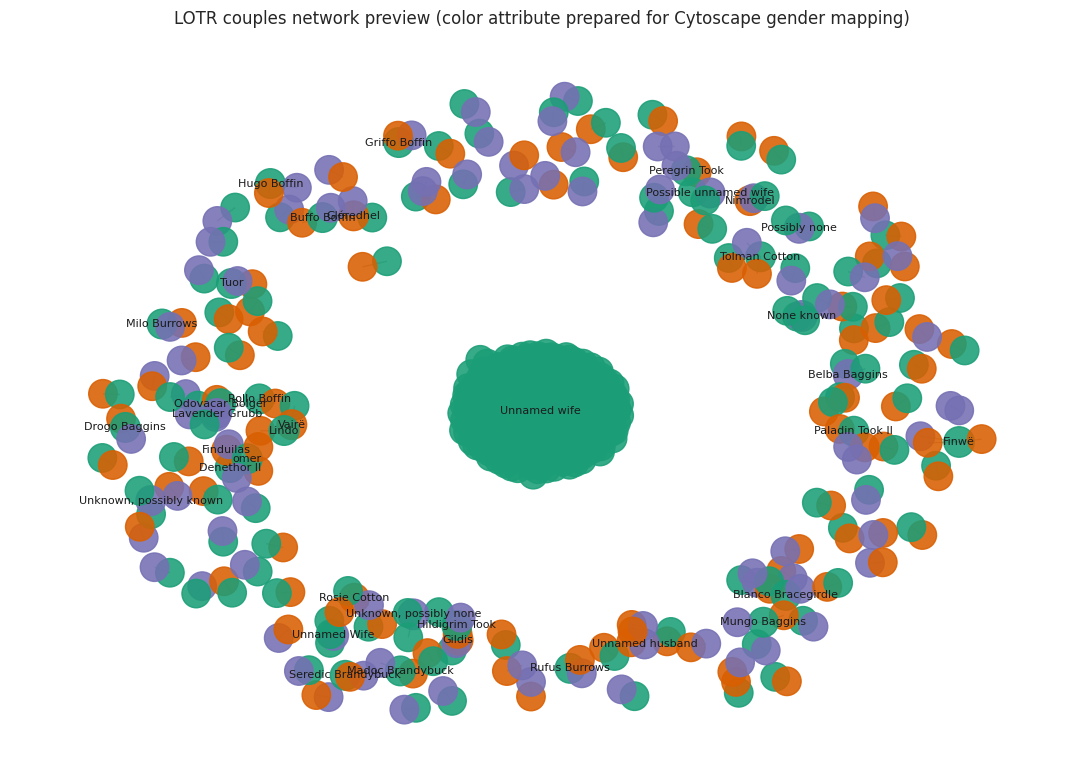

Saved preview figure: exports/figures/a7_lotr_couples_preview.png
Exported Cytoscape GraphML: exports/cytoscape/lotr_couples_gender_race.graphml
Exported Gephi GEXF: exports/gephi/lotr_couples_gender_race.gexf


In [10]:
lotr_df = pd.read_csv(LOTR_CSV)
lotr_df["name"] = lotr_df["name"].astype(str).str.strip()
lotr_df["spouse"] = lotr_df["spouse"].astype("string").str.strip()
lotr_df["gender"] = lotr_df["gender"].fillna("Unknown").astype(str).str.strip()
lotr_df["race"] = lotr_df["race"].fillna("Unknown").astype(str).str.strip()

attr_by_name = lotr_df.set_index("name")[["gender", "race"]].to_dict("index")
lotr_graph = nx.Graph()
for _, row in lotr_df.iterrows():
    name = row["name"]
    spouse = row["spouse"]
    if not name or name.lower() == "nan":
        continue
    lotr_graph.add_node(name, gender=row["gender"], race=row["race"], label=name)
    if pd.notna(spouse) and spouse and spouse.lower() not in {"nan", "none", "unknown"}:
        lotr_graph.add_node(spouse, label=spouse, **attr_by_name.get(spouse, {"gender": "Unknown", "race": "Unknown"}))
        if name != spouse:
            lotr_graph.add_edge(name, spouse, relationship="spouse")

# Keep the couples network: remove isolated characters without a spouse edge.
isolates = list(nx.isolates(lotr_graph))
lotr_graph.remove_nodes_from(isolates)

gender_colors = {
    "Female": "#d95f02",
    "Male": "#1b9e77",
    "Unknown": "#7570b3",
    "nan": "#7570b3",
}
race_shapes = {
    "Men": "ELLIPSE",
    "Elves": "DIAMOND",
    "Hobbits": "ROUND_RECTANGLE",
    "Dwarves": "RECTANGLE",
    "Ainur": "TRIANGLE",
    "Orcs": "HEXAGON",
    "Dragon": "OCTAGON",
    "Unknown": "ELLIPSE",
}
for node, data in lotr_graph.nodes(data=True):
    gender = data.get("gender", "Unknown")
    race = data.get("race", "Unknown")
    data["cytoscape_color"] = gender_colors.get(gender, gender_colors["Unknown"])
    data["cytoscape_shape"] = race_shapes.get(race, "ELLIPSE")
    data["degree"] = int(lotr_graph.degree(node))
    data["viz_size"] = 28 + 7 * math.sqrt(max(lotr_graph.degree(node), 1))

lotr_graphml_path = CYTOSCAPE_DIR / "lotr_couples_gender_race.graphml"
lotr_gexf_path = GEPHI_DIR / "lotr_couples_gender_race.gexf"
nx.write_graphml(lotr_graph, lotr_graphml_path)
nx.write_gexf(lotr_graph, lotr_gexf_path)

lotr_summary = pd.DataFrame([
    {"nodes": lotr_graph.number_of_nodes(), "edges": lotr_graph.number_of_edges(), "removed_isolates": len(isolates), "cytoscape_file": str(lotr_graphml_path.relative_to(PROJECT_ROOT)), "gephi_file": str(lotr_gexf_path.relative_to(PROJECT_ROOT))}
])
display(lotr_summary)
display(lotr_df[["name", "spouse", "gender", "race"]].dropna(subset=["spouse"]).head(15))

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(lotr_graph, seed=RANDOM_SEED, k=0.8)
node_colors = [lotr_graph.nodes[n].get("cytoscape_color", "#7570b3") for n in lotr_graph.nodes]
node_sizes = [lotr_graph.nodes[n].get("viz_size", 30) * 12 for n in lotr_graph.nodes]
nx.draw_networkx_edges(lotr_graph, pos, alpha=0.35)
nx.draw_networkx_nodes(lotr_graph, pos, node_color=node_colors, node_size=node_sizes, alpha=0.88)
label_nodes = {n: n for n, d in lotr_graph.degree() if d >= 2}
nx.draw_networkx_labels(lotr_graph, pos, labels=label_nodes, font_size=8)
plt.title("LOTR couples network preview (color attribute prepared for Cytoscape gender mapping)")
plt.axis("off")
fig_path_a7 = save_current_figure("a7_lotr_couples_preview.png")
plt.show()
print(f"Saved preview figure: {fig_path_a7.relative_to(PROJECT_ROOT)}")
print(f"Exported Cytoscape GraphML: {lotr_graphml_path.relative_to(PROJECT_ROOT)}")
print(f"Exported Gephi GEXF: {lotr_gexf_path.relative_to(PROJECT_ROOT)}")


### LOTR Cytoscape screenshot

![Cytoscape visualization of the LOTR couples network colored by gender and shaped by race](../exports/figures/cytoscape_lotr_gender_race.png)

This Cytoscape view shows the spouse/couple network after applying the selected visual encodings. Gender is represented by node color, race is represented by node shape, and node size is tied to degree so repeated or connected couple relationships are easier to notice.

Suggested Cytoscape styling used for this screenshot:

1. Import `exports/cytoscape/lotr_couples_gender_race.graphml`.
2. Set node label to `label`.
3. Map fill color to `gender`, or directly use `cytoscape_color` as a passthrough/manual color guide.
4. Map node shape to `race`, using `cytoscape_shape` as the suggested shape field.
5. Map node size to `viz_size` or `degree`.
6. Use a force-directed layout and manually separate overlapping couple pairs.

**Interpretation.** The exported graph represents spouse/couple edges. Coloring by gender makes the composition of relationships easier to scan, and shaping by race makes cross-race and same-race pairings visible once styled in Cytoscape.

### How I solved this task

I read `lotr_characters.csv`, built an undirected graph from the `name` and `spouse` columns, added node attributes from `gender` and `race`, removed characters without spouse edges from the couples network, and exported the result to GraphML for Cytoscape. I also exported a GEXF copy for Gephi as an extra reusable file. After the Cytoscape screenshot was created manually, I inserted it into this notebook.

**Limitations.** The CSV has missing spouse, gender, or race values for some characters. I kept unknown values as `Unknown` rather than guessing. Some spouse names may appear as text but not have their own full attribute row, so those nodes also receive `Unknown` attributes.


## Part A Output Summary

This final cell lists the generated figures and graph export files so the grader or student can find them quickly.


In [11]:
summary_files = []
for folder, label in [(FIGURES_DIR, "figure"), (CYTOSCAPE_DIR, "cytoscape_export"), (GEPHI_DIR, "gephi_export")]:
    for path in sorted(folder.glob("*")):
        if path.is_file():
            summary_files.append({"type": label, "path": str(path.relative_to(PROJECT_ROOT)), "size_kb": round(path.stat().st_size / 1024, 1)})
summary_df = pd.DataFrame(summary_files)
display(summary_df)

print("Manual screenshot cells still needed:")
print("- A4 Cytoscape screenshot for exports/cytoscape/wolf_of_wall_street_character_network.graphml")
print("- A4 Gephi screenshot for exports/gephi/wolf_of_wall_street_character_network.gexf")
print("- A7 Cytoscape screenshot for exports/cytoscape/lotr_couples_gender_race.graphml")


,type,path,size_kb
0,figure,exports/figures/a1_1_degree_distribution.png,136.5
1,figure,exports/figures/a1_2_movie_graph_embedding.png,179.1
2,figure,exports/figures/a2_top12_pagerank_subgraph.png,585.5
3,figure,exports/figures/a3_pagerank_triangles_shortest...,138.3
4,figure,exports/figures/a5_jordan_belfort_ego_network.png,647.2
5,figure,exports/figures/a6_fics_sampled_top_players.png,557.4
6,figure,exports/figures/a7_lotr_couples_preview.png,655.5
7,cytoscape_export,exports/cytoscape/fics_sampled_top_players.gra...,95.1
8,cytoscape_export,exports/cytoscape/lotr_couples_gender_race.gra...,196.9
9,cytoscape_export,exports/cytoscape/wolf_of_wall_street_characte...,70.6


Manual screenshot cells still needed:
- A4 Cytoscape screenshot for exports/cytoscape/wolf_of_wall_street_character_network.graphml
- A4 Gephi screenshot for exports/gephi/wolf_of_wall_street_character_network.gexf
- A7 Cytoscape screenshot for exports/cytoscape/lotr_couples_gender_race.graphml
